Estimated slope (complex Hopf simulation): 0.6010189193940811


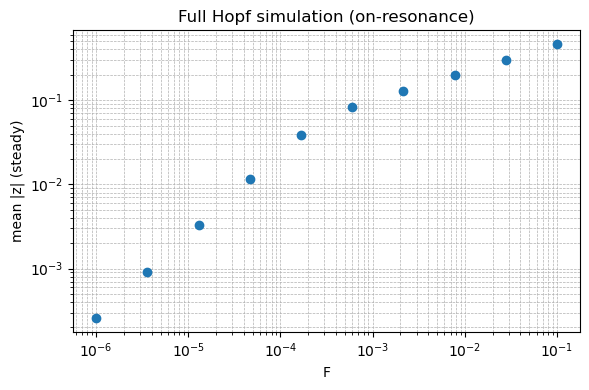

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def rhs(z, t, mu, omega0, beta, F, omega_drive):
    return (mu + 1j*omega0)*z - (1 + 1j*beta)*(np.abs(z)**2)*z + F*np.exp(1j*omega_drive*t)

def rk4_step(z, t, dt, f, *args):
    k1 = f(z, t, *args)
    k2 = f(z + 0.5*dt*k1, t + 0.5*dt, *args)
    k3 = f(z + 0.5*dt*k2, t + 0.5*dt, *args)
    k4 = f(z + dt*k3, t + dt, *args)
    return z + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def simulate_once(F, mu=0.1, omega0=2*np.pi*1.0, beta=0.0, omega_drive=None, dt=0.005, t_end=400.0):
    if omega_drive is None:
        omega_drive = omega0
    n_steps = int(np.ceil(t_end/dt))
    t = np.linspace(0, t_end, n_steps)
    z = np.zeros(n_steps, dtype=complex)
    z[0] = 1e-6 + 1e-6j
    for n in range(n_steps-1):
        z[n+1] = rk4_step(z[n], t[n], dt, rhs, mu, omega0, beta, F, omega_drive)
    # measure mean amplitude from last 30% of time series
    cut = int(0.7 * n_steps)
    return np.mean(np.abs(z[cut:])), t, z

# Try a sweep over F
Fs = np.logspace(-6, -1, 10)
amps = []
for F in Fs:
    amp, _, _ = simulate_once(F, mu=0.0, omega0=2*np.pi*1.0, beta=0.0, omega_drive=2*np.pi*1.0,
                              dt=0.005, t_end=300.0)
    amps.append(amp)

amps = np.array(amps)
slope, intercept = np.polyfit(np.log10(Fs[4:-4]), np.log10(amps[4:-4]), 1)
print("Estimated slope (complex Hopf simulation):", slope)

plt.figure(figsize=(6,4))
plt.loglog(Fs, amps, marker='o', linestyle='none')
plt.xlabel('F')
plt.ylabel('mean |z| (steady)')
plt.title('Full Hopf simulation (on-resonance)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()
